In [1]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [2]:
sys.path.append('./fashion-mnist/utils/')

In [3]:
import mnist_reader
x_train, t_train = mnist_reader.load_mnist('./fashion-mnist/data/fashion', kind='train')
x_test, t_test = mnist_reader.load_mnist('./fashion-mnist/data/fashion', kind='t10k')

# ## data normalization
# x_train = x_train / 255.0
# x_test = x_test / 255.0 

In [4]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(60000, 784)
255
(60000,)


In [5]:
network_dict = {
                'step': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='step', weight_init_std=0.01),
                'sigmoid': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='sigmoid', weight_init_std=0.01),
                'tanh': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='tanh', weight_init_std=0.01),
                'relu': MultiLayerNetExtend(input_size=784, hidden_size_list=[50], output_size=10, activation='relu', weight_init_std=0.01),
                'leaky': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std=0.01),
                }

In [6]:
network_dict['relu'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2'])

In [7]:
# 하이퍼 파라메터
iters_num = 10_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [8]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== step network training start ===


--- step result report ---
train acc, test acc | 0.16571666666666668, 0.1654
--- step result report ---
train acc, test acc | 0.73085, 0.7231
--- step result report ---
train acc, test acc | 0.7490666666666667, 0.7404
--- step result report ---
train acc, test acc | 0.7518166666666667, 0.7441
--- step result report ---
train acc, test acc | 0.7526833333333334, 0.7433
--- step result report ---
train acc, test acc | 0.7537, 0.7443
--- step result report ---
train acc, test acc | 0.7564166666666666, 0.7467
--- step result report ---
train acc, test acc | 0.7580666666666667, 0.7465
--- step result report ---
train acc, test acc | 0.75985, 0.752
--- step result report ---
train acc, test acc | 0.7606833333333334, 0.7485
--- step result report ---
train acc, test acc | 0.76015, 0.7483
--- step result report ---
train acc, test acc | 0.76165, 0.7515
--- step result report ---
train acc, test acc | 0.7632333333333333, 0.7506
--- step result report ---
train acc, test acc | 0.7627666666666667,

/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


--- sigmoid result report ---
train acc, test acc | 0.6346166666666667, 0.6252
--- sigmoid result report ---
train acc, test acc | 0.6789333333333334, 0.6738
--- sigmoid result report ---
train acc, test acc | 0.6299, 0.6199
--- sigmoid result report ---
train acc, test acc | 0.6217666666666667, 0.6169
--- sigmoid result report ---
train acc, test acc | 0.6458333333333334, 0.6336
--- sigmoid result report ---
train acc, test acc | 0.7060166666666666, 0.7024
--- sigmoid result report ---
train acc, test acc | 0.64005, 0.6309
--- sigmoid result report ---
train acc, test acc | 0.65755, 0.6455
--- sigmoid result report ---
train acc, test acc | 0.6937166666666666, 0.6823
--- sigmoid result report ---
train acc, test acc | 0.6774833333333333, 0.6679
--- sigmoid result report ---
train acc, test acc | 0.6155833333333334, 0.605
--- sigmoid result report ---
train acc, test acc | 0.6847166666666666, 0.679
--- sigmoid result report ---
train acc, test acc | 0.6762666666666667, 0.6597
--- sigmo

/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:56: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size


--- relu result report ---
train acc, test acc | 0.11166666666666666, 0.1111
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1, 0.1
--- relu result report ---
train acc, test acc | 0.1,

/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/multi_layer_net_extend.py:153: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/multi_layer_net_extend.py:153: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/home/jongbin/OneDrive_korea/2_My-Programming/0_DL_from_scratch/experiment/MLP_activation_function/../../official_github/common/functions.py:34: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1
--- leaky result report ---
train acc, test acc | 0.1, 0.1





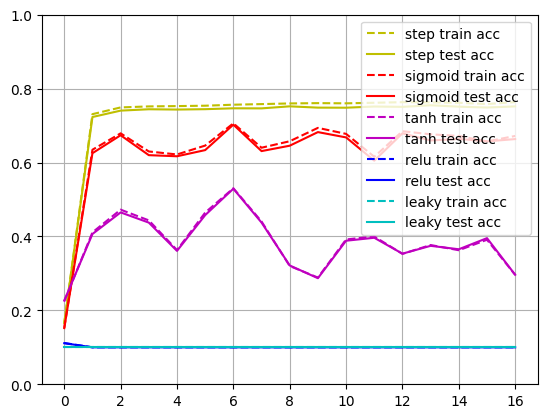

In [9]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend()
plt.grid()